# Pneumonia Detection using a VGG16-style CNN

This notebook implements a simple pneumonia detection pipeline using chest X-ray images. The goal is binary classification:

- `0` = Normal
- `1` = Pneumonia

The model is a VGG16-style CNN trained from scratch. The notebook uses a clear train/validation/internal-test workflow, reports medically relevant metrics, and generates predictions for the unlabelled external Kaggle test images.

Important data-handling point:

- `stage_2_train_labels.csv` contains labels, so it is used for training, validation, and measurable internal testing.
- `stage_2_test_images_png` contains external test images, but the provided files do not contain ground-truth labels for those images.
- Therefore, the internal labelled test split is used for accuracy, recall, F1-score, and confusion matrix.
- The external test folder is used only to produce final predictions.

## 1. Dataset access

This cell downloads or locates the RSNA pneumonia dataset.

In [1]:
#install data locally
import os
os.environ["KAGGLEHUB_CACHE"] = "./data"

import kagglehub

# Download latest version
path = kagglehub.dataset_download("stevezeyuzhang/rsna-pneumonia-detection-challenge")
print("Path to dataset files:", path)


Path to dataset files: /kaggle/input/datasets/stevezeyuzhang/rsna-pneumonia-detection-challenge


## 2. Imports

The notebook uses TensorFlow/Keras for the CNN model, Pandas for label handling, scikit-learn for splitting and metrics, and Matplotlib for visualisation.

In [6]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import os

from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
from keras.metrics import Recall, Precision

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


2026-06-26 00:38:17.303529: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782434297.493027      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782434297.547799      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782434298.017560      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782434298.017599      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782434298.017602      58 computation_placer.cc:177] computation placer alr

## 3. Configuration

This section defines the dataset paths, image size, batch size, learning rate, and whether to use a smaller training subset. For quick experiments, `USE_SMALL_TRAIN_SET = True` is useful. For the final best run, it should be set to `False`.

In [8]:
# defining constants
BASE_DIR = "/kaggle/input/datasets/stevezeyuzhang/rsna-pneumonia-detection-challenge/rsna-pneumonia-detection-challenge"

TRAIN_IMG_DIR = BASE_DIR + "/stage_2_train_images_png"
TEST_IMG_DIR  = BASE_DIR + "/stage_2_test_images_png"

CSV_PATH = BASE_DIR + "/stage_2_train_labels.csv"
CLASS_INFO_PATH = BASE_DIR + "/stage_2_detailed_class_info.csv"
SAMPLE_SUBMISSION_PATH = BASE_DIR + "/stage_2_sample_submission.csv"

IMG_SIZE      = (224, 224)
BATCH_SIZE    = 64
EPOCHS        = 50
LR            = 0.00001

# For faster experiments. Set this to False for final training.
USE_SMALL_TRAIN_SET = False
TRAIN_FRAC = 0.4


## 4. Data preparation and splitting

The official external test folder does not contain labels in the provided files, so it cannot be used for accuracy, recall, F1-score, or confusion matrix.

Because of that, the labelled CSV is split into three parts:

1. **Training set**: used to update the neural network weights.
2. **Validation set**: used for training decisions and threshold selection.
3. **Internal test set**: kept untouched until final evaluation.

The external Kaggle test images are loaded separately with `class_mode=None`, because they have no labels.

In [ ]:
df = pd.read_csv(CSV_PATH)

# stage_2_train_labels.csv is the labelled data.
# one row per patient as each patient either has pneumonia or not.
df = df.drop_duplicates("patientId").reset_index(drop=True)

# Filename to match PNG filename
df["filename"] = df["patientId"] + ".png"

# Labels must be strings for flow_from_dataframe with class_mode="binary"
df["Target"] = df["Target"].astype(str)

print(f"Total labelled patients : {len(df)}")
print(f"Normal  (0)            : {(df['Target'] == '0').sum()}")
print(f"Pneumonia (1)          : {(df['Target'] == '1').sum()}")


# - stage_2_detailed_class_info.csv gives extra class information for the labelled training patients.
# - stage_2_sample_submission.csv gives patient IDs for the external test images, but no true labels.
class_info = pd.read_csv(CLASS_INFO_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print("\nClass info columns:", list(class_info.columns))
print("Sample submission columns:", list(sample_submission.columns))
print("External test images:", len(sample_submission))

# Because the external Kaggle test set has no labels here, we cannot compute accuracy/recall/F1 on it.
# So we create an internal labelled test set from the labelled training CSV for final measurable evaluation.

# Split 1: train+validation vs internal test.
# The internal test set is kept untouched until final evaluation.
train_val_df, internal_test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["Target"],
    random_state=42
)

# Split 2: train vs validation.
# Validation is used during training and threshold tuning.
# 0.17647 of 85% gives approximately 15% of the original full dataset.
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.17647,
    stratify=train_val_df["Target"],
    random_state=42
)

# Smaller training subset for faster experiments.
# groupby("Target") keeps approximately the same class ratio in the smaller sample.
if USE_SMALL_TRAIN_SET:
    train_df_used = (
        train_df
        .groupby("Target", group_keys=False)
        .sample(frac=TRAIN_FRAC, random_state=42)
        .reset_index(drop=True)
    )
else:
    train_df_used = train_df.copy()

print("\nTrain full       :", len(train_df))
print("Train used       :", len(train_df_used))
print("Validation       :", len(val_df))
print("Internal test    :", len(internal_test_df))
print("External test    :", len(sample_submission), "(unlabelled, predictions only)")

# Augmentation for the training set only
train_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    shear_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
)

# No augmentation for validation/test; only rescaling.
# This makes evaluation stable and fair.
eval_aug = ImageDataGenerator(rescale=1./255)

traindata = train_aug.flow_from_dataframe(
    dataframe=train_df_used,
    directory=TRAIN_IMG_DIR,
    x_col="filename",
    y_col="Target",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
)

valdata = eval_aug.flow_from_dataframe(
    dataframe=val_df,
    directory=TRAIN_IMG_DIR,
    x_col="filename",
    y_col="Target",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False,
)

internal_testdata = eval_aug.flow_from_dataframe(
    dataframe=internal_test_df,
    directory=TRAIN_IMG_DIR,
    x_col="filename",
    y_col="Target",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# External Kaggle test images: no labels, so class_mode=None.
# This is used only to generate predictions, not metrics.
external_test_df = sample_submission[["patientId"]].copy()
external_test_df["filename"] = external_test_df["patientId"] + ".png"

external_testdata = eval_aug.flow_from_dataframe(
    dataframe=external_test_df,
    directory=TEST_IMG_DIR,
    x_col="filename",
    y_col=None,
    target_size=IMG_SIZE,
    class_mode=None,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

Total labelled patients : 26684
Normal  (0)            : 20672
Pneumonia (1)          : 6012

Class info columns: ['patientId', 'class']
Sample submission columns: ['patientId', 'PredictionString']
External test images: 3000

Train full       : 18678
Train used       : 18678
Validation       : 4003
Internal test    : 4003
External test    : 3000 (unlabelled, predictions only)
Found 18678 validated image filenames belonging to 2 classes.
Found 4003 validated image filenames belonging to 2 classes.
Found 4003 validated image filenames belonging to 2 classes.
Found 3000 validated image filenames.


## 5. VGG16-style CNN architecture

The model follows the task description. The final layer uses a single sigmoid neuron because this is a binary classification problem: Normal vs Pneumonia.

The model is trained from scratch, meaning pretrained ImageNet weights are not used.

In [10]:


model = Sequential()
 
# Block 1
model.add(Conv2D(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), filters=64, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model.add(BatchNormalization())
 
# Block 2
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model.add(BatchNormalization())
 
# Block 3
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model.add(BatchNormalization())
 
# Block 4
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model.add(BatchNormalization())
 
# Block 5
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model.add(BatchNormalization())
 
# Classifier head
model.add(Flatten())
model.add(Dense(units=4096, activation="relu"))
model.add(Dropout(0.5))                        # prevent overfitting
model.add(Dense(units=4096, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(units=1, activation="sigmoid", dtype='float32')) # binary output
 
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1782434402.204884      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 512)      │         2,04

 Total params: 134,270,529 (512.20 MB)

 Trainable params: 134,267,585 (512.19 MB)

 Non-trainable params: 2,944 (11.50 KB)

## 6. Compilation and callbacks

The model uses binary cross-entropy because there are two classes. Besides accuracy, the notebook tracks precision, recall, ROC-AUC, and PR-AUC.

The checkpoint saves the best model according to validation PR-AUC. PR-AUC is useful here because the dataset is imbalanced: there are many more normal patients than pneumonia patients.

In [11]:
opt = Adam(learning_rate=LR)

model.compile(
    optimizer=opt,
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="roc_auc", curve="ROC"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
    ],
)

os.makedirs("models", exist_ok=True)

checkpoint = ModelCheckpoint(
    "models/vgg16_pneumonia_best.keras",
    monitor="val_pr_auc",
    save_best_only=True,
    mode="max",
    verbose=1,
)

early = EarlyStopping(
    monitor="val_pr_auc",
    patience=10,
    mode="max",
    verbose=1,
    restore_best_weights=True,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1,
)


## 7. Quick sanity checks

This checks whether a GPU is visible and confirms the class mapping. The important point is that pneumonia should correspond to class `1`, because the sigmoid output is interpreted as pneumonia probability.

In [ ]:
# This cell was added to check Kaggle's notebook environment saw the GPU.
print(tf.config.list_physical_devices('GPU'))
print(traindata.class_indices)
# Should print: {'0': 0, '1': 1}
# Pneumonia should be 1

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
{'0': 0, '1': 1}


## 8. Class imbalance handling

The dataset contains more normal cases than pneumonia cases. Class weights make pneumonia samples count more during training, which helps the model avoid simply predicting the majority class.

In [13]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df_used["Target"].astype(int),
)

class_weights = {0: weights[0], 1: weights[1]}
print("Class weights:", class_weights)


Class weights: {0: np.float64(0.6454042847270214), 1: np.float64(2.219344106463878)}


## 9. Model training


In [14]:
# Training the model.

hist = model.fit(
    traindata,
    steps_per_epoch=len(traindata),
    validation_data=valdata,
    validation_steps=len(valdata),
    epochs=EPOCHS,
    callbacks=[checkpoint, early, reduce_lr],
    class_weight=class_weights,
)


Epoch 1/50


I0000 00:00:1782434444.697187     139 service.cc:152] XLA service 0x782af8008510 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782434444.697225     139 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782434446.020366     139 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782434485.581479     139 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6225 - loss: 0.8215 - pr_auc: 0.3493 - precision: 0.3209 - recall: 0.6064 - roc_auc: 0.6578
Epoch 1: val_pr_auc improved from None to 0.27914, saving model to models/vgg16_pneumonia_best.keras

Epoch 1: finished saving model to models/vgg16_pneumonia_best.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 1149s 4s/step - accuracy: 0.6479 - loss: 0.7560 - pr_auc: 0.3856 - precision: 0.3471 - recall: 0.6388 - roc_auc: 0.6966 - val_accuracy: 0.7744 - val_loss: 0.6249 - val_pr_auc: 0.2791 - val_precision: 0.4000 - val_recall: 0.0022 - val_roc_auc: 0.5646 - learning_rate: 1.0000e-05
Epoch 2/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6766 - loss: 0.6735 - pr_auc: 0.4470 - precision: 0.3869 - recall: 0.6822 - roc_auc: 0.7402
Epoch 2: val_pr_auc improved from 0.27914 to 0.51132, saving model to models/vgg16_pneumonia_best.keras

Epoch 2: finished saving model to models/vgg16_pneumonia_best.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 782s 3s/step - acc

## 10. Training curves

These plots show how the model behaved during training. They help identify underfitting, overfitting, or plateauing. The most useful curves here are validation loss, validation recall, ROC-AUC, and PR-AUC.

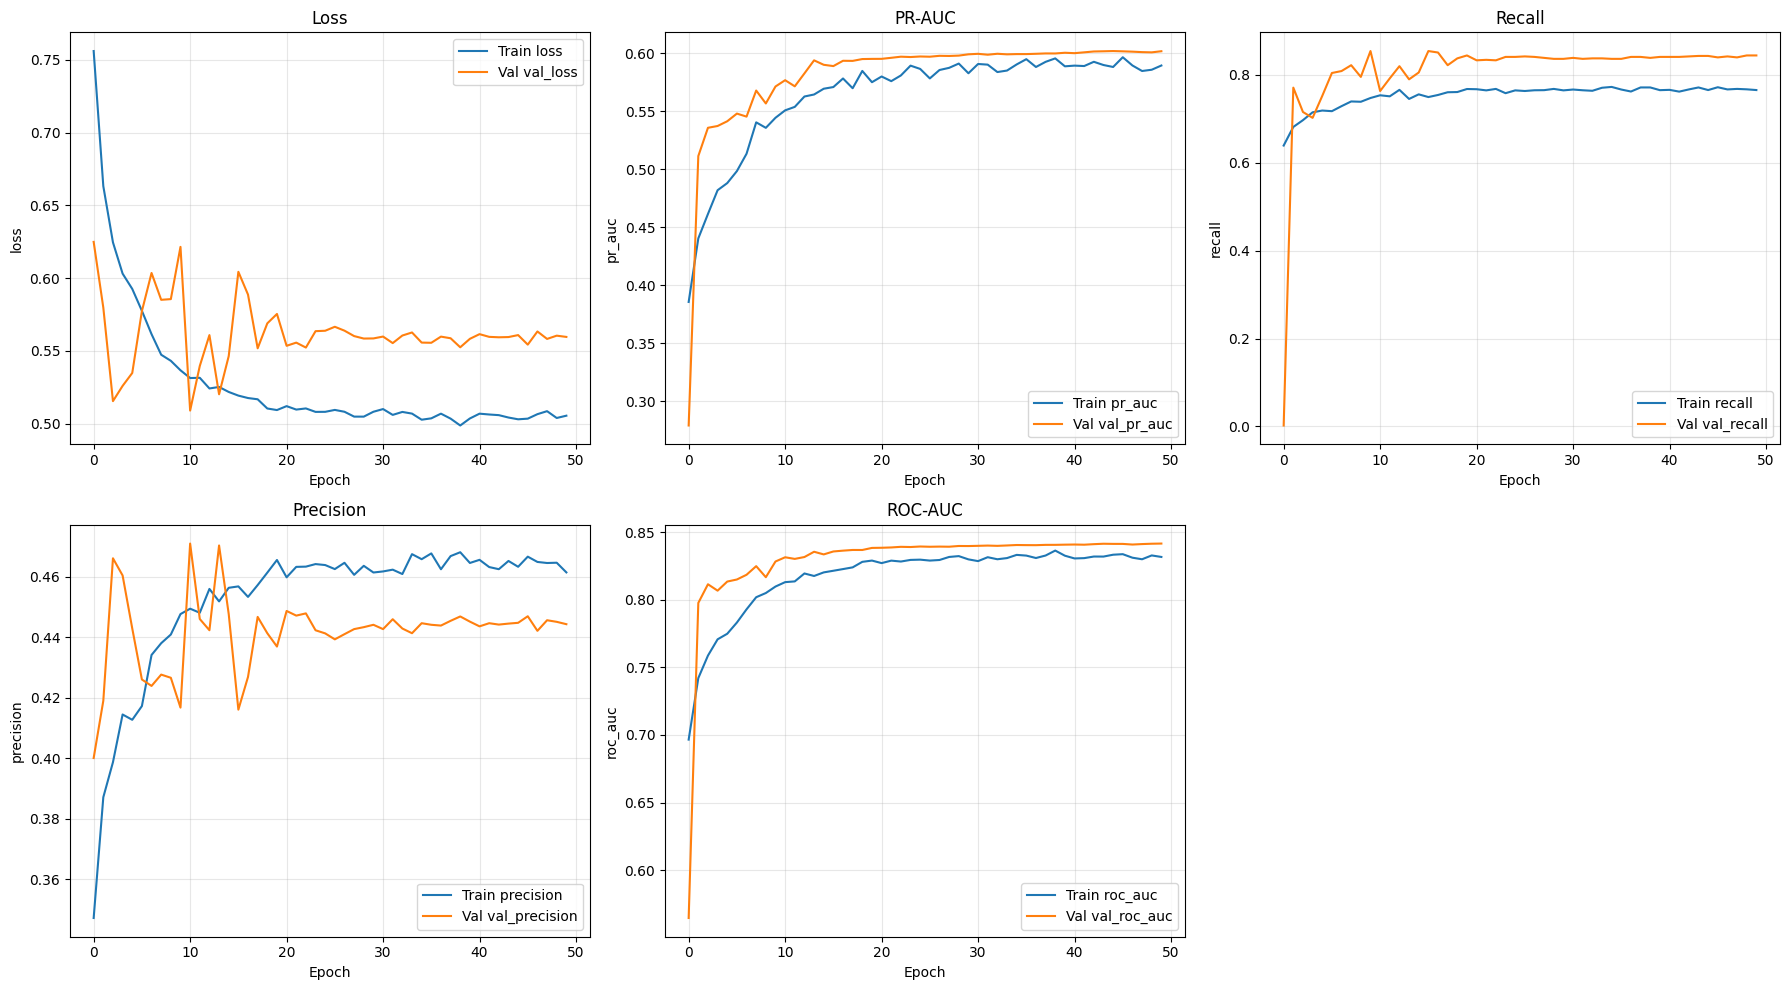

In [15]:
history = hist.history  

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

def plot_metric(ax, train_key, val_key, title):
    if train_key in history and val_key in history:
        ax.plot(history[train_key], label=f"Train {train_key}")
        ax.plot(history[val_key], label=f"Val {val_key}")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(train_key)
        ax.legend()
        ax.grid(alpha=0.3)
    else:
        ax.set_title(f"{title} (not found)")
        ax.axis("off")

plot_metric(axes[0], "loss", "val_loss", "Loss")
plot_metric(axes[1], "pr_auc", "val_pr_auc", "PR-AUC")
plot_metric(axes[2], "recall", "val_recall", "Recall")
plot_metric(axes[3], "precision", "val_precision", "Precision")
plot_metric(axes[4], "roc_auc", "val_roc_auc", "ROC-AUC")

# Hide last empty subplot (2x3 grid has 6 slots, we used 5)
axes[5].axis("off")

plt.tight_layout()
plt.savefig("training_curves_updated.png", dpi=150)
plt.show()


In [ ]:
# For downloading the best model to my computer, I had to move the model from one directory to another.
import shutil
from pathlib import Path

MODEL_PATH = Path("/kaggle/working/models/vgg16_pneumonia_best.keras")
OUTPUT_PATH = Path("/kaggle/working/vgg16_pneumonia_best.keras")

shutil.copy(MODEL_PATH, OUTPUT_PATH)

print("Model copied to:", OUTPUT_PATH)

Model copied to: /kaggle/working/vgg16_pneumonia_best.keras


## 11. Threshold selection on validation data

The model outputs probabilities, not direct labels. A threshold converts each probability into a class:

- probability below threshold → Normal
- probability above threshold → Pneumonia

Instead of blindly using `0.50`, this cell tests several thresholds and chooses the one with the best validation F1-score. The validation set is allowed to be used for this decision.

In [17]:
saved_model = tf.keras.models.load_model("models/vgg16_pneumonia_best.keras")

# Predict probabilities on the validation set
valdata.reset()
val_probs = saved_model.predict(valdata).flatten()
val_true = valdata.classes

# Try different probability thresholds.
# Lower threshold usually gives higher recall but more false positives.
thresholds = np.arange(0.10, 0.91, 0.05)
results = []

for t in thresholds:
    val_pred = (val_probs >= t).astype(int)
    p = precision_score(val_true, val_pred, zero_division=0)
    r = recall_score(val_true, val_pred, zero_division=0)
    f1 = f1_score(val_true, val_pred, zero_division=0)
    results.append([t, p, r, f1])

results_df = pd.DataFrame(results, columns=["threshold", "precision", "recall", "f1"])
print(results_df.round(4))

# Choose the threshold with the best validation F1-score.
best_idx = results_df["f1"].idxmax()
best_t = float(results_df.loc[best_idx, "threshold"])

print(f"\nBest threshold by F1: {best_t:.2f}")
print(results_df.loc[best_idx].round(4))

val_pred_best = (val_probs >= best_t).astype(int)

print("\nValidation classification report using best threshold:")
print(classification_report(val_true, val_pred_best, target_names=["Normal", "Pneumonia"]))

print("Validation confusion matrix:")
print(confusion_matrix(val_true, val_pred_best))


63/63 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step
    threshold  precision  recall      f1
0        0.10     0.2497  0.9956  0.3993
1        0.15     0.2698  0.9889  0.4240
2        0.20     0.2867  0.9767  0.4433
3        0.25     0.3085  0.9623  0.4672
4        0.30     0.3352  0.9523  0.4958
5        0.35     0.3574  0.9268  0.5159
6        0.40     0.3831  0.9024  0.5378
7        0.45     0.4141  0.8792  0.5630
8        0.50     0.4447  0.8426  0.5822
9        0.55     0.4650  0.8016  0.5885
10       0.60     0.4930  0.7450  0.5934
11       0.65     0.5253  0.6907  0.5967
12       0.70     0.5537  0.6286  0.5888
13       0.75     0.5845  0.5366  0.5595
14       0.80     0.6149  0.4390  0.5123
15       0.85     0.6711  0.3348  0.4467
16       0.90     0.7305  0.2073  0.3230

Best threshold by F1: 0.65
threshold    0.6500
precision    0.5253
recall       0.6907
f1           0.5967
Name: 11, dtype: float64

Validation classification report using best threshold:
              precision    recall

## 12. Recall-focused threshold

A lower threshold, such as `0.45`, usually increases pneumonia recall. That means fewer pneumonia cases are missed, but more normal X-rays are incorrectly flagged as pneumonia.

This is not the main threshold, but it is useful to show the medical tradeoff between false negatives and false positives.

In [18]:
# Optional: using a fixed lower threshold to increase recall
# This is useful if missing pneumonia cases is considered worse than extra false alarms.
fixed_t = 0.45
val_pred_fixed = (val_probs >= fixed_t).astype(int)

print(f"\nValidation classification report using fixed threshold = {fixed_t:.2f}:")
print(classification_report(val_true, val_pred_fixed, target_names=["Normal", "Pneumonia"]))

print("Validation confusion matrix:")
print(confusion_matrix(val_true, val_pred_fixed))



Validation classification report using fixed threshold = 0.45:
              precision    recall  f1-score   support

      Normal       0.95      0.64      0.76      3101
   Pneumonia       0.41      0.88      0.56       902

    accuracy                           0.69      4003
   macro avg       0.68      0.76      0.66      4003
weighted avg       0.83      0.69      0.72      4003

Validation confusion matrix:
[[1979 1122]
 [ 109  793]]


## 13. Final internal test evaluation with the validation-selected threshold

This is the main final measurable result. The threshold was selected on validation data, then applied once to the untouched internal test set.

For `sklearn.metrics.confusion_matrix`, the layout is:

```text
[[True Normal,  False Pneumonia],
 [False Normal, True Pneumonia]]
```

In other words:

- top-left = normal images correctly classified as normal
- top-right = normal images incorrectly classified as pneumonia
- bottom-left = pneumonia images incorrectly classified as normal
- bottom-right = pneumonia images correctly classified as pneumonia

63/63 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step

Final INTERNAL TEST results using validation-selected threshold = 0.65
              precision    recall  f1-score   support

      Normal       0.90      0.83      0.86      3101
   Pneumonia       0.54      0.69      0.60       902

    accuracy                           0.80      4003
   macro avg       0.72      0.76      0.73      4003
weighted avg       0.82      0.80      0.80      4003

Internal test confusion matrix:
[[2563  538]
 [ 281  621]]


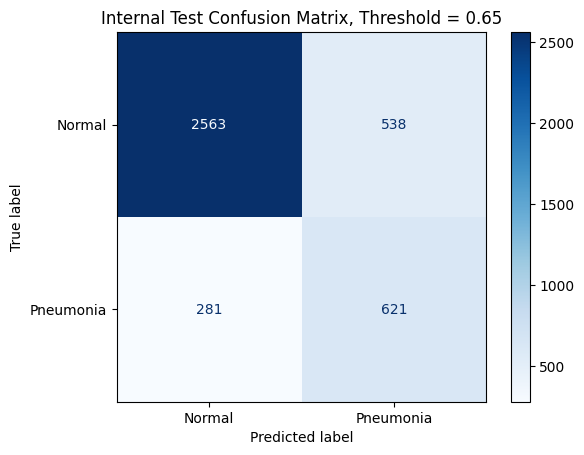

In [ ]:
# Final measurable evaluation using the internal labelled test set
# The threshold was selected using the validation set
internal_testdata.reset()
test_probs = saved_model.predict(internal_testdata).flatten()
test_true = internal_testdata.classes

test_pred = (test_probs >= best_t).astype(int)

print(f"\nFinal INTERNAL TEST results using validation-selected threshold = {best_t:.2f}")
print(classification_report(test_true, test_pred, target_names=["Normal", "Pneumonia"]))

cm_best = confusion_matrix(test_true, test_pred)
print("Internal test confusion matrix:")
print(cm_best)

ConfusionMatrixDisplay(cm_best, display_labels=["Normal", "Pneumonia"]).plot(cmap="Blues")
plt.title(f"Internal Test Confusion Matrix, Threshold = {best_t:.2f}")
plt.show()


## 14. Final internal test evaluation with the fixed recall-focused threshold

This repeats the final test evaluation using the lower threshold `0.45`. It is not the main F1-selected threshold, but it shows what happens when we prioritise catching more pneumonia cases.

63/63 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step

Final INTERNAL TEST results using fixed threshold = 0.45
              precision    recall  f1-score   support

      Normal       0.94      0.64      0.76      3101
   Pneumonia       0.41      0.87      0.56       902

    accuracy                           0.69      4003
   macro avg       0.68      0.75      0.66      4003
weighted avg       0.82      0.69      0.71      4003

Internal test confusion matrix:
[[1971 1130]
 [ 121  781]]


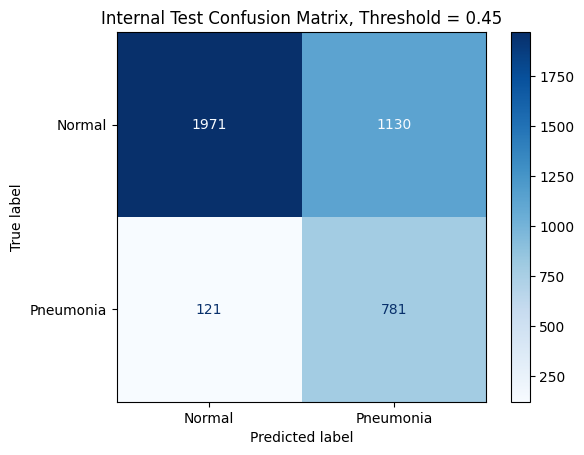

In [20]:
# Final measurable evaluation using the fixed recall-focused threshold.
# This cell uses the same internal labelled test set.
internal_testdata.reset()
test_probs = saved_model.predict(internal_testdata).flatten()
test_true = internal_testdata.classes

test_pred_fixed = (test_probs >= fixed_t).astype(int)

print(f"\nFinal INTERNAL TEST results using fixed threshold = {fixed_t:.2f}")
print(classification_report(test_true, test_pred_fixed, target_names=["Normal", "Pneumonia"]))

cm_fixed = confusion_matrix(test_true, test_pred_fixed)
print("Internal test confusion matrix:")
print(cm_fixed)

ConfusionMatrixDisplay(cm_fixed, display_labels=["Normal", "Pneumonia"]).plot(cmap="Blues")
plt.title(f"Internal Test Confusion Matrix, Threshold = {fixed_t:.2f}")
plt.show()


## 15. External Kaggle test predictions

The external test images have no ground-truth labels in the provided files. Therefore, this cell only creates predictions and saves them to a CSV file. It cannot compute accuracy, recall, F1-score, or a confusion matrix.

In [21]:
# Predict on the external Kaggle test images.
# These images have no labels in the provided files, so this produces predictions only.
# It does not produce accuracy, recall, F1-score, or a confusion matrix.

external_testdata.reset()
external_probs = saved_model.predict(external_testdata).flatten()

external_predictions = external_test_df.copy()
external_predictions["pneumonia_probability"] = external_probs
external_predictions["predicted_label"] = np.where(
    external_predictions["pneumonia_probability"] >= best_t,
    "PNEUMONIA",
    "NORMAL"
)

external_predictions.to_csv("external_test_predictions.csv", index=False)

print(external_predictions.head())
print("Saved predictions to external_test_predictions.csv")


47/47 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step
                              patientId  \
0  0000a175-0e68-4ca4-b1af-167204a7e0bc   
1  0005d3cc-3c3f-40b9-93c3-46231c3eb813   
2  000686d7-f4fc-448d-97a0-44fa9c5d3aa6   
3  000e3a7d-c0ca-4349-bb26-5af2d8993c3d   
4  00100a24-854d-423d-a092-edcf6179e061   

                                   filename  pneumonia_probability  \
0  0000a175-0e68-4ca4-b1af-167204a7e0bc.png               0.053442   
1  0005d3cc-3c3f-40b9-93c3-46231c3eb813.png               0.426341   
2  000686d7-f4fc-448d-97a0-44fa9c5d3aa6.png               0.122173   
3  000e3a7d-c0ca-4349-bb26-5af2d8993c3d.png               0.198928   
4  00100a24-854d-423d-a092-edcf6179e061.png               0.806119   

  predicted_label  
0          NORMAL  
1          NORMAL  
2          NORMAL  
3          NORMAL  
4       PNEUMONIA  
Saved predictions to external_test_predictions.csv


## 16. Optional single-image prediction demo

This helper function is optional. It is useful if we want to show how the saved model can classify one new X-ray image. It is not required for training or final evaluation.

In [22]:
from tensorflow.keras.preprocessing import image


def predict_xray(img_path, model_path="models/vgg16_pneumonia_best.keras", threshold=0.5):
    """
    Predict whether one chest X-ray image is Normal or Pneumonia.

    Parameters:
        img_path: path to the image file
        model_path: path to the saved trained model
        threshold: probability threshold for the Pneumonia class

    Returns:
        label and predicted pneumonia probability
    """
    saved_model = tf.keras.models.load_model(model_path)
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = np.expand_dims(np.asarray(img) / 255.0, axis=0)

    prob = saved_model.predict(img_array)[0][0]
    label = "PNEUMONIA" if prob >= threshold else "NORMAL"

    print(f"Prediction : {label}  (pneumonia probability: {prob:.2f})")
    return label, prob
